Discharge perturbation sensitivity (threshold > 0.10 m)
Reference area: 13,959.96 km²
+20% Q area:    13,960.40 km²  (+0.00 % vs ref)
-20% Q area:    13,959.72 km²  (-0.00 % vs ref)


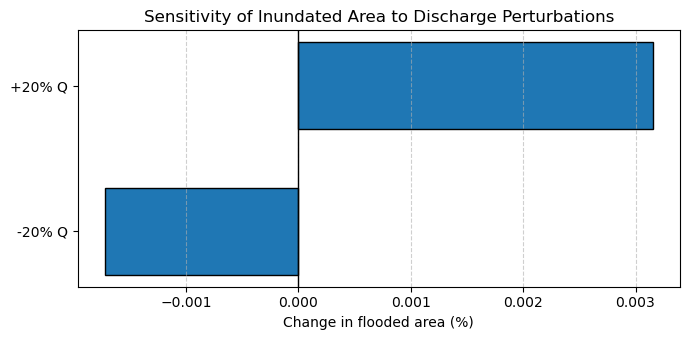

In [4]:
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, calculate_default_transform, Resampling
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, os

# ---------------- CONFIG ----------------
THRESHOLD = 0.1  # meters
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
shapefile_extract_path = r"D:\Phd Research\GIS\Shape\unzipped"

ref_file    = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
q_plus_20   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_P_20_stat.tif"
q_minus_20  = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_Q_M20_stat.tif"
# ----------------------------------------

# --- Unzip and read boundary shapefile once ---
if not os.path.isdir(shapefile_extract_path) or not any(f.endswith(".shp") for f in os.listdir(shapefile_extract_path)):
    with zipfile.ZipFile(boundary_zip, 'r') as zip_ref:
        zip_ref.extractall(shapefile_extract_path)

shapefile = [os.path.join(shapefile_extract_path, f) for f in os.listdir(shapefile_extract_path) if f.endswith(".shp")][0]
gdf_boundary = gpd.read_file(shapefile)

def _area_from_mask_bool(mask_bool, src_crs, src_transform, pixel_area_hint=None):
    """Return area [m^2] of True pixels in mask_bool.
       If crs is projected in meters, use pixel area directly.
       If geographic, reproject to equal-area (EPSG:5070) and count."""
    from rasterio.crs import CRS
    crs = CRS.from_user_input(src_crs) if src_crs else None
    if crs and not crs.is_geographic:
        # projected in meters
        if pixel_area_hint is None:
            ax = abs(src_transform.a); ay = abs(src_transform.e)
            pixel_area_hint = ax * ay
        return int(mask_bool.sum()) * pixel_area_hint
    else:
        # geographic -> reproject boolean mask to equal-area grid
        dst_crs = "EPSG:5070"  # NAD83 / Conus Albers (good for TX)
        h, w = mask_bool.shape
        left, bottom, right, top = rasterio.transform.array_bounds(h, w, src_transform)
        dst_transform, dst_w, dst_h = calculate_default_transform(
            src_crs, dst_crs, w, h, left, bottom, right, top, resolution=100.0  # ~100 m pixels
        )
        src_arr = mask_bool.astype("uint8")
        dst_arr = np.zeros((dst_h, dst_w), dtype="uint8")
        reproject(
            source=src_arr, destination=dst_arr,
            src_transform=src_transform, src_crs=src_crs,
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=Resampling.nearest
        )
        pix_area = abs(dst_transform.a) * abs(dst_transform.e)  # m^2/pixel
        return int(dst_arr.sum()) * pix_area

# --- Compute inundated area (>THRESHOLD) within boundary for any raster ---
def compute_inundated_area(raster_path):
    with rasterio.open(raster_path) as src:
        # 1) Reproject boundary to raster CRS
        boundary_in_src = gdf_boundary.to_crs(src.crs)

        # 2) Clip; use filled=False so outside is a proper mask
        out, out_transform = mask(
            src, boundary_in_src.geometry, crop=True,
            all_touched=True, filled=False
        )
        data = out[0]  # MaskedArray

        # 3) Build wet mask: inside boundary, valid, and depth > threshold
        valid = ~data.mask & np.isfinite(data)
        wet = valid & (data > THRESHOLD)

        # 4) Area (m^2)
        pixel_area_m2 = abs(src.transform.a) * abs(src.transform.e)
        area_m2 = _area_from_mask_bool(
            wet, src.crs, out_transform, pixel_area_hint=pixel_area_m2
        )
        return area_m2

# --- Compute areas ---
area_ref_m2   = compute_inundated_area(ref_file)
area_qp_m2    = compute_inundated_area(q_plus_20)
area_qm_m2    = compute_inundated_area(q_minus_20)

m2_to_km2 = 1e-6
area_ref_km2 = area_ref_m2 * m2_to_km2
area_qp_km2  = area_qp_m2  * m2_to_km2
area_qm_km2  = area_qm_m2  * m2_to_km2

pct_change_qp = ((area_qp_m2 - area_ref_m2) / area_ref_m2) * 100.0
pct_change_qm = ((area_qm_m2 - area_ref_m2) / area_ref_m2) * 100.0

print(f"Discharge perturbation sensitivity (threshold > {THRESHOLD:.2f} m)")
print(f"Reference area: {area_ref_km2:,.2f} km²")
print(f"+20% Q area:    {area_qp_km2:,.2f} km²  ({pct_change_qp:+.2f} % vs ref)")
print(f"-20% Q area:    {area_qm_km2:,.2f} km²  ({pct_change_qm:+.2f} % vs ref)")

# --- Plot ---
labels = ["-20% Q", "+20% Q"]
pct_changes = [pct_change_qm, pct_change_qp]
y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(y, pct_changes, height=0.6, edgecolor="black")
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel("Change in flooded area (%)")
ax.set_title("Sensitivity of Inundated Area to Discharge Perturbations")
ax.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()
